# TCS Stock Price Prediction Using LSTM (Long Short-Term Memory)

### **Project Overview:**  
This project aims to build a predictive model for Tata Consultancy Services (TCS) stock prices using Long Short-Term Memory (LSTM), a Machine Learning technique. The model will estimate future stock prices based on historical market data and key financial indicators.

**Why LSTM for Stock Prediction?**  
LSTMs are a special type of Recurrent Neural Network (RNN) designed for sequential data, such as stock prices that change over time. Unlike traditional models, LSTMs:

- Remember past trends and use them for future predictions.
- Handle long-term dependencies, making them ideal for time-series forecasting.
- Overcome the vanishing gradient problem, ensuring efficient learning from past stock patterns.

By leveraging LSTM's ability to learn patterns over time, this model aims to enhance stock price forecasting accuracy and support better investment decisions.

**Goal:**  
Predict the closing stock price (`Close`) for each day in the test dataset based on various stock market attributes, evaluated using Mean Squared Error (MSE) and R-Squared Score metrics.

**Dataset Description:**  
The dataset comprises historical stock data for TCS, containing:

- **Key financial indicators:** `Open`, `High`, `Low`, `Close`, `Volume`
- **Market events:** `Stock splits`, `Dividends`
- **Temporal features:** `Date`

### **Methodological Approach:**

**1. Data Loading and Exploration**
- Read the stock dataset.
- Identify and handle missing values.
- Detect outliers using visualization techniques.

**2. Exploratory Data Analysis (EDA)**
- Perform statistical summaries and visualizations.
- Analyze price trends and seasonality.
- Compute correlation among features.
- Remove irrelevant or redundant variables.

**3. Data Preprocessing**
- Standardize numerical variables.
- Apply feature engineering (Moving Averages, Lag Features, Volatility Measures).
- Split the dataset into **training and testing sets** (80-20 split, random state: 31).

**4. Model Development**
- Perform **Backward Elimination** using OLS regression.
- Remove unnecessary features based on **p-values and feature importance**.
- Train a **Linear Regression model** using selected features.
- Implement **Regularization techniques** (Ridge, Lasso Regression).

**5. Model Evaluation**
- Compute **training and testing errors** to check for overfitting.
- Analyze multicollinearity using **Variance Inflation Factor (VIF)**.
- Optimize hyperparameters using **Grid Search**.
- Evaluate final model performance using **MSE, RMSE, and R-Squared Score**.

**6. Prediction and Deployment**
- Use the best-performing model to **forecast stock prices**.
- Visualize **actual vs. predicted prices**.
- Generate output in the required format for decision-making.

---

### **Key Challenges and Solutions:**

**1. Missing Data:**
- **Numerical features:** Impute using **mean/median**.
- **Market events (Dividends, Splits):** Forward-fill method.

**2. Multicollinearity:**
- **Variance Inflation Factor (VIF) analysis** to drop redundant features.
- **Regularization (Ridge, Lasso) to penalize overfitting.**

**3. Feature Selection:**
- **Statistical significance testing (p-values, correlation analysis).**
- **Domain knowledge integration** to select meaningful financial indicators.

**4. Model Robustness:**
- **Train-test split (80-20) with random_state.**
- **Regularization techniques to handle overfitting.**
- **Performance metric optimization to improve accuracy.**

---

**Author:** Nihal Thakare  
**Date:** 31/03/2025  
**Institution:** Unified Mentor

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import datetime

In [72]:
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tqdm import tqdm


### Reading the dataset 

In [73]:
data = pd.read_csv('TCS_stock_history.csv')

In [74]:
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0


### Exploratory Data Analysis (EDA)

In [75]:
# Setting up the Temporal features as the Date Time variable
data['Date'] = pd.to_datetime(data['Date'])

In [76]:
data.sort_values(by = 'Date', inplace = True)

In [77]:
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0


In [78]:
data.isna().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          4463 non-null   datetime64[ns]
 1   Open          4463 non-null   float64       
 2   High          4463 non-null   float64       
 3   Low           4463 non-null   float64       
 4   Close         4463 non-null   float64       
 5   Volume        4463 non-null   int64         
 6   Dividends     4463 non-null   float64       
 7   Stock Splits  4463 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 313.8 KB


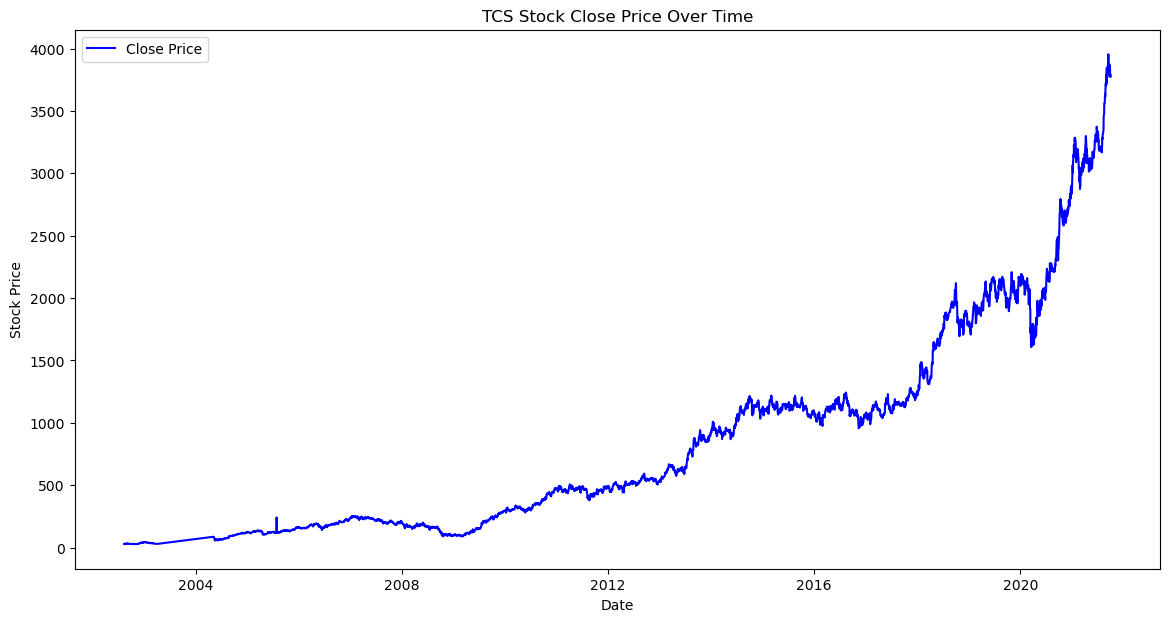

In [80]:
# Plotting Close price over time
plt.figure(figsize=(14, 7))
plt.plot(data['Date'], data['Close'], color='blue',
label='Close Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('TCS Stock Close Price Over Time')
plt.legend()
plt.show()

In [81]:
# Calculating 50-day and 200-day moving averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

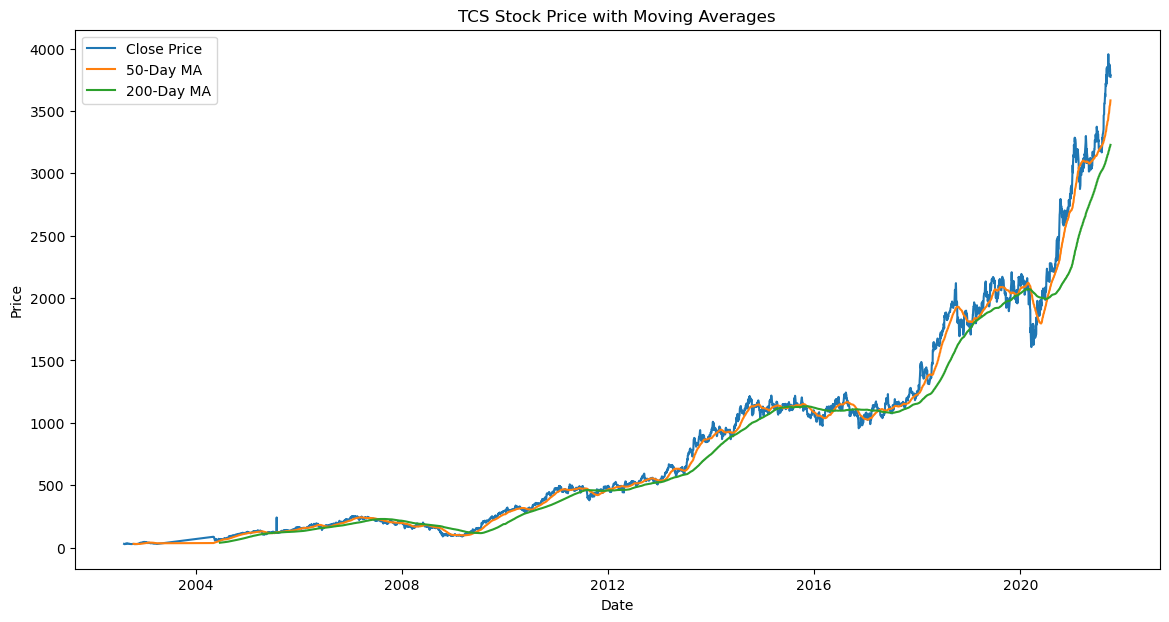

In [82]:
# Plot with Moving Averages
plt.figure(figsize=(14, 7))
plt.plot(data['Date'], data['Close'], label='Close Price')
plt.plot(data['Date'], data['MA50'], label='50-Day MA')
plt.plot(data['Date'], data['MA200'], label='200-Day MA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('TCS Stock Price with Moving Averages')
plt.legend()
plt.show()

In [83]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['Day_of_Week'] = data['Date'].dt.dayofweek


In [84]:
# Lag Features
data['Prev_Close'] = data['Close'].shift(1)


In [85]:
# Dropping rows with NaN/Missing values from shifting
data.dropna(inplace=True)

In [86]:
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA50,MA200,Year,Month,Day,Day_of_Week,Prev_Close
199,2004-06-21,66.919920,68.407029,64.540547,65.451401,49328,0.0,0.0,53.539858,38.361673,2004,6,21,0,66.157806
200,2004-06-22,65.432855,65.618744,63.573967,63.927155,20064,0.0,0.0,54.208315,38.533714,2004,6,22,1,65.451401
201,2004-06-23,64.596334,65.061056,61.584935,62.681683,22912,0.0,0.0,54.837176,38.701525,2004,6,23,2,63.927155
202,2004-06-24,63.192893,64.317518,61.919554,63.722672,21592,0.0,0.0,55.496152,38.884579,2004,6,24,3,62.681683
203,2004-06-25,63.202185,65.061073,63.202185,63.722672,60280,0.0,0.0,56.147134,39.067632,2004,6,25,4,63.722672


### Investigating corelations between the varibles to define multicollinearity

data.drop(columns = ['Date'], inplace = True)
data.head()

In [87]:
corel=data.corr()
corel

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA50,MA200,Year,Month,Day,Day_of_Week,Prev_Close
Open,1.000000,0.999883,0.999887,0.999776,-0.198837,0.057655,-0.008115,0.996948,0.989297,0.903899,-0.009586,-0.000442,0.000601,0.999935
High,0.999883,1.000000,0.999860,0.999910,-0.196315,0.057962,-0.007995,0.997019,0.989460,0.904173,-0.010224,0.000025,0.000428,0.999846
Low,0.999887,0.999860,1.000000,0.999896,-0.200474,0.057832,-0.008018,0.996792,0.989098,0.903744,-0.009185,-0.000204,0.000269,0.999838
Close,0.999776,0.999910,0.999896,1.000000,-0.198311,0.058102,-0.008033,0.996858,0.989252,0.904005,-0.009692,0.000146,0.000202,0.999729
Volume,-0.198837,-0.196315,-0.200474,-0.198311,1.000000,-0.013343,0.003861,-0.202287,-0.208166,-0.267088,-0.023877,0.055815,0.048135,-0.198644
Dividends,0.057655,0.057962,0.057832,0.058102,-0.013343,1.000000,0.142424,0.059121,0.061458,0.060757,-0.001680,0.012632,-0.003745,0.057681
Stock Splits,-0.008115,-0.007995,-0.008018,-0.008033,0.003861,0.142424,1.000000,-0.009252,-0.010607,-0.008394,-0.004128,0.027824,0.012677,-0.007971
MA50,0.996948,0.997019,0.996792,0.996858,-0.202287,0.059121,-0.009252,1.000000,0.994216,0.910383,-0.009882,0.001638,0.000842,0.997014
MA200,0.989297,0.989460,0.989098,0.989252,-0.208166,0.061458,-0.010607,0.994216,1.000000,0.922456,-0.017941,0.002603,0.001014,0.989404
Year,0.903899,0.904173,0.903744,0.904005,-0.267088,0.060757,-0.008394,0.910383,0.922456,1.000000,-0.078486,-0.006166,0.000893,0.904179


In [88]:
# Correlation of features with the target variable (Close Price)
correlation_with_close = data.corr()['Close'].sort_values(ascending=False)
print(correlation_with_close)


Close           1.000000
High            0.999910
Low             0.999896
Open            0.999776
Prev_Close      0.999729
MA50            0.996858
MA200           0.989252
Year            0.904005
Dividends       0.058102
Day_of_Week     0.000202
Day             0.000146
Stock Splits   -0.008033
Month          -0.009692
Volume         -0.198311
Name: Close, dtype: float64


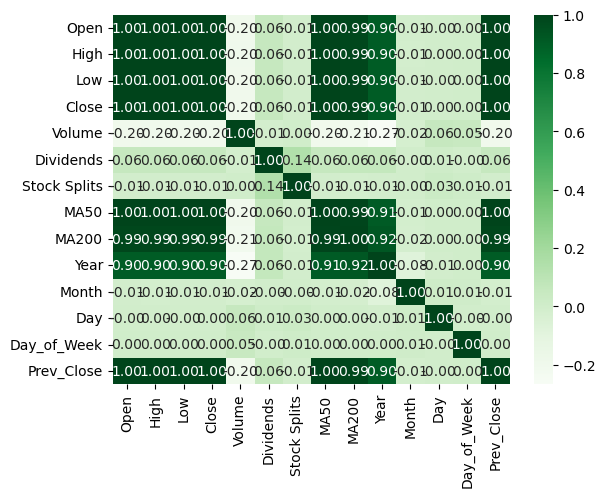

In [89]:
sns.heatmap(corel,annot= True,cmap= "Greens",fmt=".2f")
plt.show()

In [90]:
Q = pd.DataFrame(correlation_with_close)
imp_columns = Q[(Q['Close']>0.2)|(Q['Close']<-0.2)].index.tolist()
imp_columns.remove('Close')

In [91]:
imp_columns

['High', 'Low', 'Open', 'Prev_Close', 'MA50', 'MA200', 'Year']

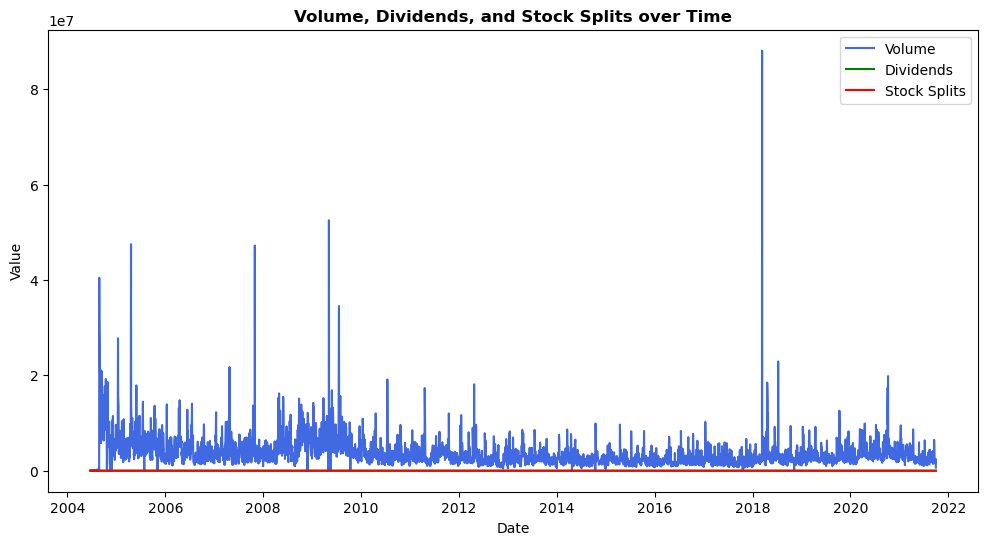

In [92]:
# Relation between Volume, Divident, Stock Splits over the time
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Volume'], label='Volume', color='royalblue')
plt.plot(data['Date'], data['Dividends'], label='Dividends', color='g')
plt.plot(data['Date'], data['Stock Splits'], label='Stock Splits', color='r')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Volume, Dividends, and Stock Splits over Time',weight = "bold")
plt.legend()
plt.show()

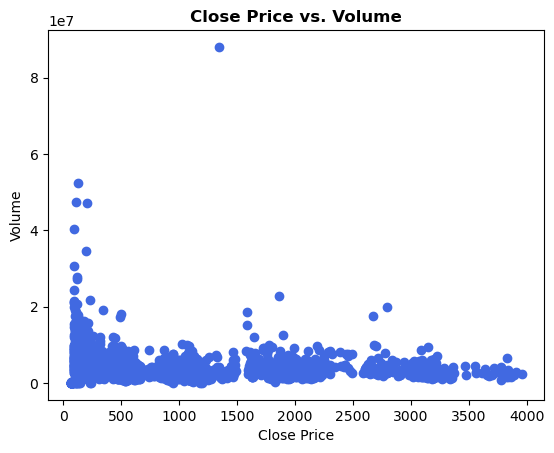

In [93]:
# Close Price vs Volume
plt.scatter(data['Close'], data['Volume'], color = 'royalblue')
plt.xlabel('Close Price')
plt.ylabel('Volume')
plt.title('Close Price vs. Volume',weight= "bold")
plt.show()


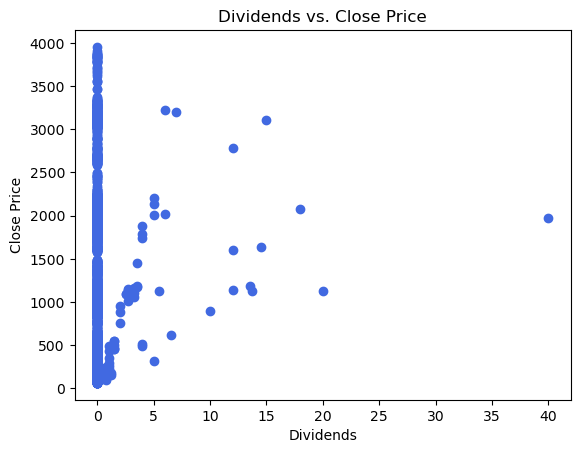

In [94]:
plt.scatter(data['Dividends'], data['Close'], color='royalblue')
plt.xlabel('Dividends')
plt.ylabel('Close Price')
plt.title('Dividends vs. Close Price')
plt.show()

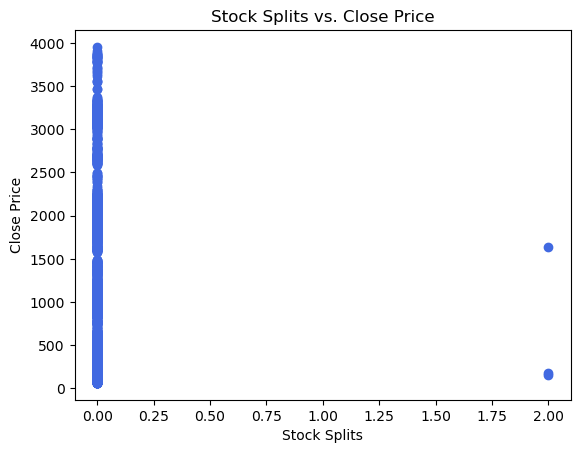

In [95]:
plt.scatter(data['Stock Splits'], data['Close'], color='royalblue')
plt.xlabel('Stock Splits')
plt.ylabel('Close Price')
plt.title('Stock Splits vs. Close Price')
plt.show()

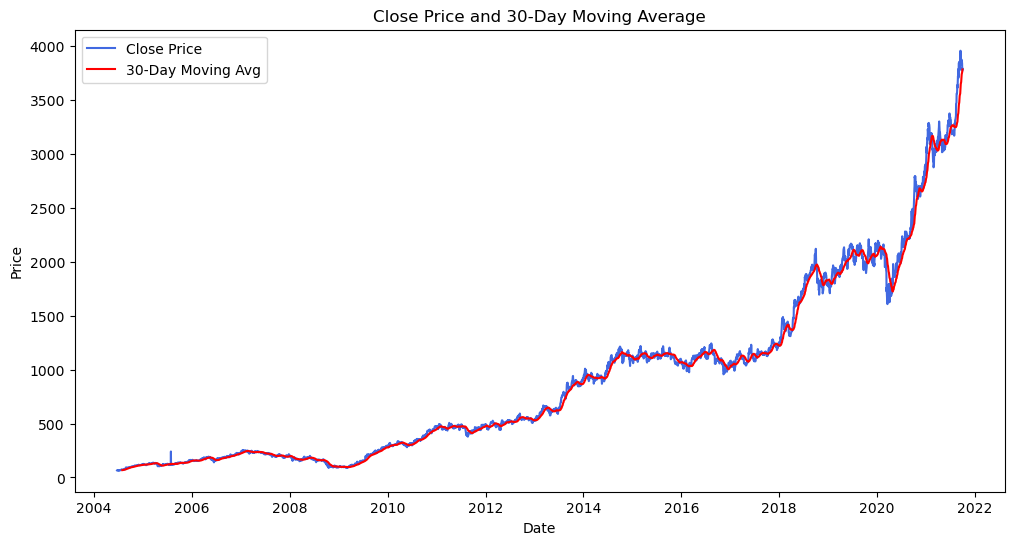

In [96]:
#Moving Averages
data['30-Day Moving Avg'] = data['Close'].rolling(window=30).mean()
# Plot Close price and moving average
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'], label='Close Price', color='royalblue')
plt.plot(data['Date'], data['30-Day Moving Avg'], label='30-Day Moving Avg', color='r')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Close Price and 30-Day Moving Average')
plt.legend()
plt.show()

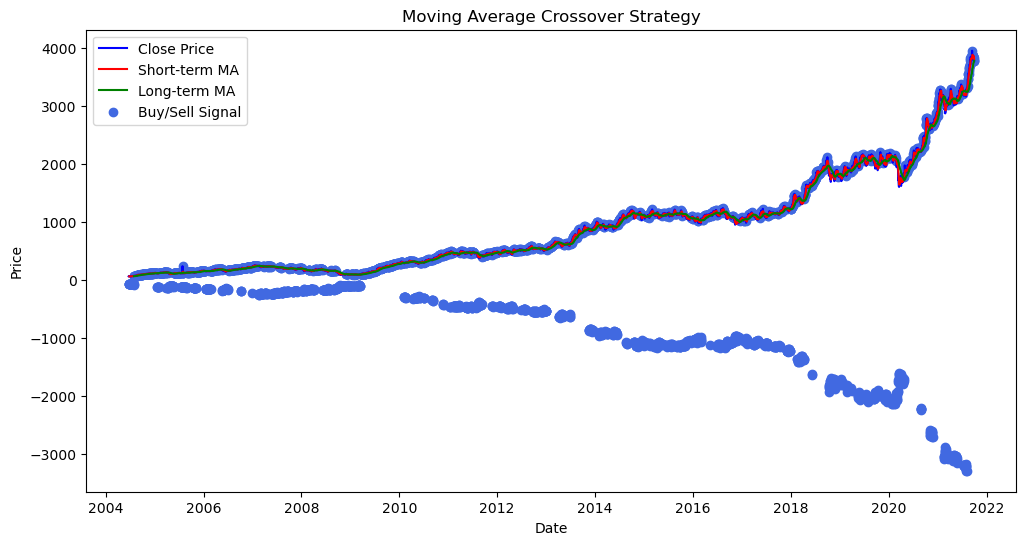

In [97]:
# Moving Average Crossover Strategy
data['Short_MA'] = data['Close'].rolling(window=5).mean()
data['Long_MA'] = data['Close'].rolling(window=30).mean()

# Creating a trading signals based on moving average crossovers
data['Signal'] = np.where(data['Short_MA'] > data['Long_MA'], 1,-1)

# Plot the strategy signals
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'], label='Close Price', color='b')
plt.plot(data['Date'], data['Short_MA'], label='Short-term MA', color='r')
plt.plot(data['Date'], data['Long_MA'], label='Long-term MA', color='g')
plt.scatter(data['Date'], data['Close'] * data['Signal'], label='Buy/Sell Signal', marker='o', color='royalblue')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Moving Average Crossover Strategy')
plt.legend()
plt.show()


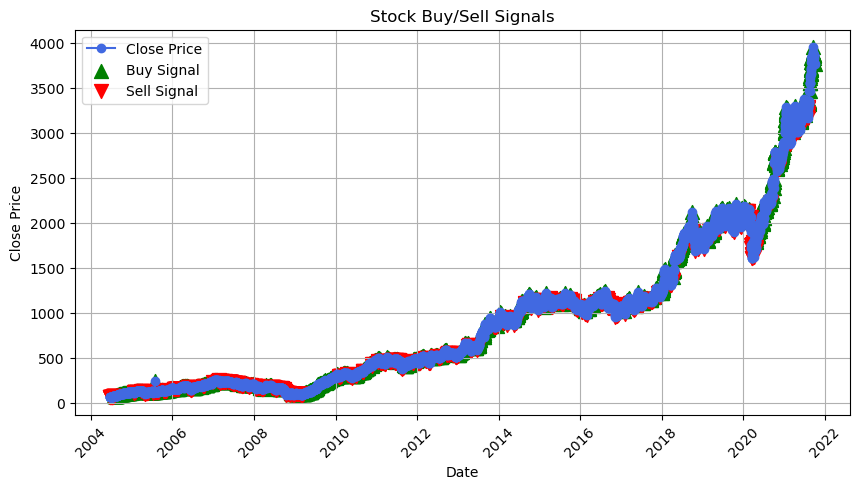

In [98]:
# Separate Buy and Sell signals
buy_signals = data[data['Signal'] == 1]
sell_signals = data[data['Signal'] == -1]

# Plot the closing price
plt.figure(figsize=(10, 5))
plt.plot(data['Date'], data['Close'], label='Close Price', color='royalblue', linestyle='-', marker='o')

# Plot Buy Signals
plt.scatter(buy_signals['Date'], buy_signals['Close'], label='Buy Signal', marker='^', color='green', s=100)

# Plot Sell Signals
plt.scatter(sell_signals['Date'], sell_signals['Close'], label='Sell Signal', marker='v', color='red', s=100)

# Formatting
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Stock Buy/Sell Signals')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Show the plot
plt.show()

In [99]:
# Daily Price Change
data['Daily_Price_Change'] = data['Close'].pct_change() * 100


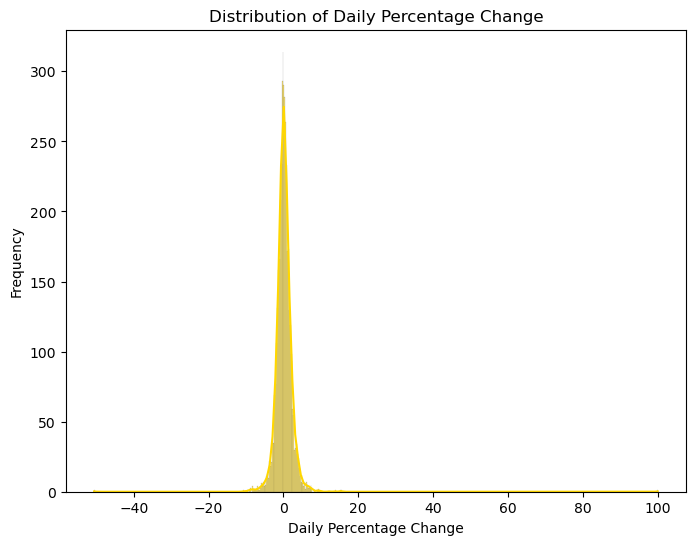

In [100]:
# Distribution of daily percentage change
plt.figure(figsize=(8, 6))
sns.histplot(data['Daily_Price_Change'].dropna(), kde=True, color = 'gold')
plt.xlabel('Daily Percentage Change')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Percentage Change')
plt.show()


In [101]:
# Feature Engineering

data['Moving_Avg_Close'] = data['Close'].rolling(window=7).mean()
# Modelling
data.shape

(4264, 21)

In [102]:
# Data Preparation & Normalization
# Prepare the data for LSTM
X_train = data['Close'].values.reshape(-1, 1)
y_train = data['Close'].shift(-1).dropna().values


In [103]:
# Normalize the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Define the test data
test_ratio = 0.2
test_size = int(len(data) * test_ratio)
test_data = data[-test_size:]



In [104]:
# Prepare the data for prediction
X_test = test_data['Close'].values.reshape(-1, 1)
X_test_scaled = scaler.transform(X_test)
X_test_lstm = X_test_scaled.reshape(-1, 1, 1)

In [105]:
# Reshape the data for LSTM
X_train_lstm = X_train_scaled[:-1].reshape(-1, 1, 1)
y_train_lstm = X_train_scaled[1:]

In [106]:
# Building a LSTM Model
model = Sequential() 
model.add(LSTM(50, input_shape=(1, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Set the number of epochs and batch size
epochs = 30
batch_size = 15

In [107]:
# Train the model with TQDM progress bar
for epoch in tqdm(range(epochs)):
    for i in range(0, len(X_train_lstm), batch_size):
        X_batch = X_train_lstm[i:i+batch_size]
        y_batch = y_train_lstm[i:i+batch_size]
        model.train_on_batch(X_batch, y_batch)

100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [04:40<00:00,  9.35s/it]


In [108]:
# Prepare the data for prediction
X_test = test_data['Close'].values.reshape(-1, 1)
X_test_scaled = scaler.transform(X_test)
X_test_lstm = X_test_scaled.reshape(-1, 1, 1)

In [109]:
# Predictions using LSTM
lstm_predictions = model.predict(X_test_lstm).flatten()

27/27 [==============================] - 1s 3ms/step


In [110]:
# Inverse transform of the predictions
lstm_predictions = lstm_predictions.reshape(-1, 1)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

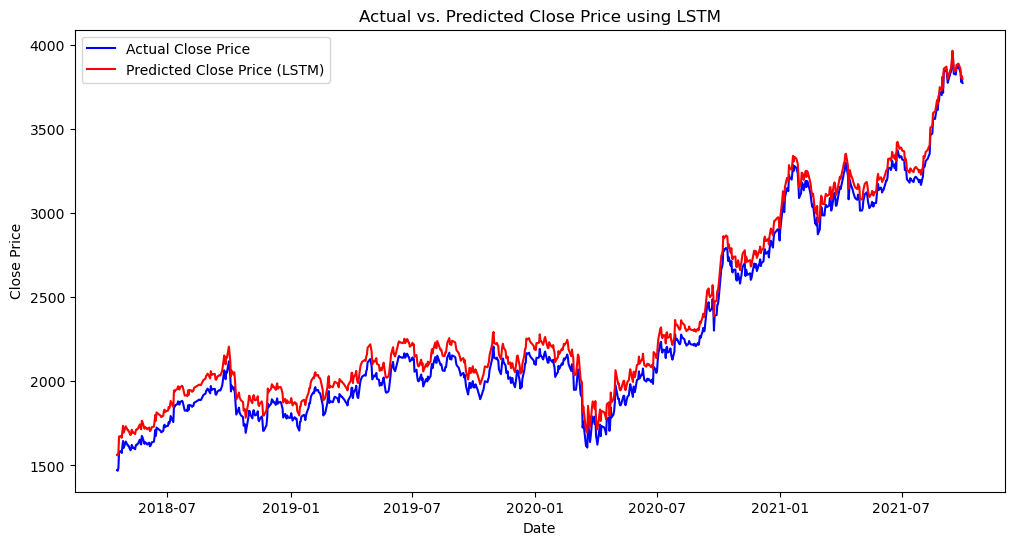

In [111]:
# Visualization of LSTM predictions
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], test_data['Close'], label='Actual Close Price', color='b')
plt.plot(test_data['Date'], lstm_predictions, label='Predicted Close Price (LSTM)', color='r')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs. Predicted Close Price using LSTM')
plt.legend()
plt.show()

In [112]:
# Mean Absolute Error
lstm_mae = mean_absolute_error(test_data['Close'],
lstm_predictions)
print("LSTM Mean Absolute Error:", lstm_mae)


LSTM Mean Absolute Error: 80.16811001916446


In [113]:
date_index = test_data.index[-len(lstm_predictions):]

In [114]:
test_data['Date'] = pd.to_datetime(test_data['Date'])

In [115]:
date_index = test_data['Date'].iloc[-len(lstm_predictions):]


In [116]:
lstm_predictions = lstm_predictions.reshape(-1, 1)
lstm_predictions = scaler.inverse_transform(lstm_predictions) 
date_index=test_data.index[-len(lstm_predictions):]
predictions_df=pd.DataFrame({'Date':date_index, 'Predicted_Close':lstm_predictions.flatten()})


In [117]:
# If they're just sequential numbers without date meaning
predictions_df = pd.DataFrame({
    'Date': test_data.index[-len(lstm_predictions):],  # use actual dates from your index
    'Predicted_Close': lstm_predictions.flatten()
})

In [118]:
print(predictions_df.head())


   Date  Predicted_Close
0  3611        6082014.5
1  3612        6068443.0
2  3613        6126433.0
3  3614        6508555.0
4  3615        6519762.0


In [119]:
predictions_df.to_csv('predictions2.csv',index=False)